In [57]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")

from llr_study.utils import *

In [2]:
%config InlineBackend.figure_format = 'retina'

In [3]:
projectdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New')
workdirs = [
    'LLR_crtd_odd',
    # 'LLR_odd_combos2to5',
    # 'LLR_odd_combos6',
    # 'LLR_odd_combos7to12',
]
file_paths = [projectdir / wd / 'fits_new' / 'summary_results.txt' for wd in workdirs]
df = parse_UL_results_files(file_paths)
df
# Save to CSV for further analysis
# output_file = "combined_llr_results.csv"
# df.to_csv(output_file, index=False)
# print(f"\nResults saved to {output_file}")


Total observables parsed: 729
llr_from_3D    543
llr_from_2D    120
llr_from_1D     66
Name: obs_type, dtype: int64


,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
0,bjets_mbb_vs_bjets_dR_llr,322.2,231.2,449.4,173.7,604.8,llr_from_2D,2
1,bjets_mean_pt_vs_bjets_dR_llr,337.9,242.8,471.2,182.8,634.2,llr_from_2D,2
2,bjets_mean_pt_vs_bjets_mbb_llr,344.9,247.8,481.1,186.6,647.4,llr_from_2D,2
3,bjets_dR_vs_bjets_pt_bb_llr,353.0,253.6,492.3,191.0,658.0,llr_from_2D,2
4,bjets_mbb_vs_bjets_pt_bb_llr,358.8,257.8,500.4,194.1,671.2,llr_from_2D,2
...,...,...,...,...,...,...,...,...
724,all_pt_llr,4000.0,3453.0,6902.0,2570.0,9409.0,llr_from_1D,1
725,all_sT_vs_bjet_bijet_dR_vs_bb_lnu_dPhi_llr,4000.0,2743.0,7157.0,1977.0,12120.0,llr_from_3D,3
726,all_sT_vs_bjet_bijet_dR_vs_bjets_dPhi_llr,4000.0,3425.0,8050.0,2289.0,12130.0,llr_from_3D,3
727,nAK4_llr,4000.0,3982.0,8050.0,3719.0,12130.0,llr_from_1D,1


CMS-style enhanced scatter plot saved to llr_scatterplot_by_type.pdf


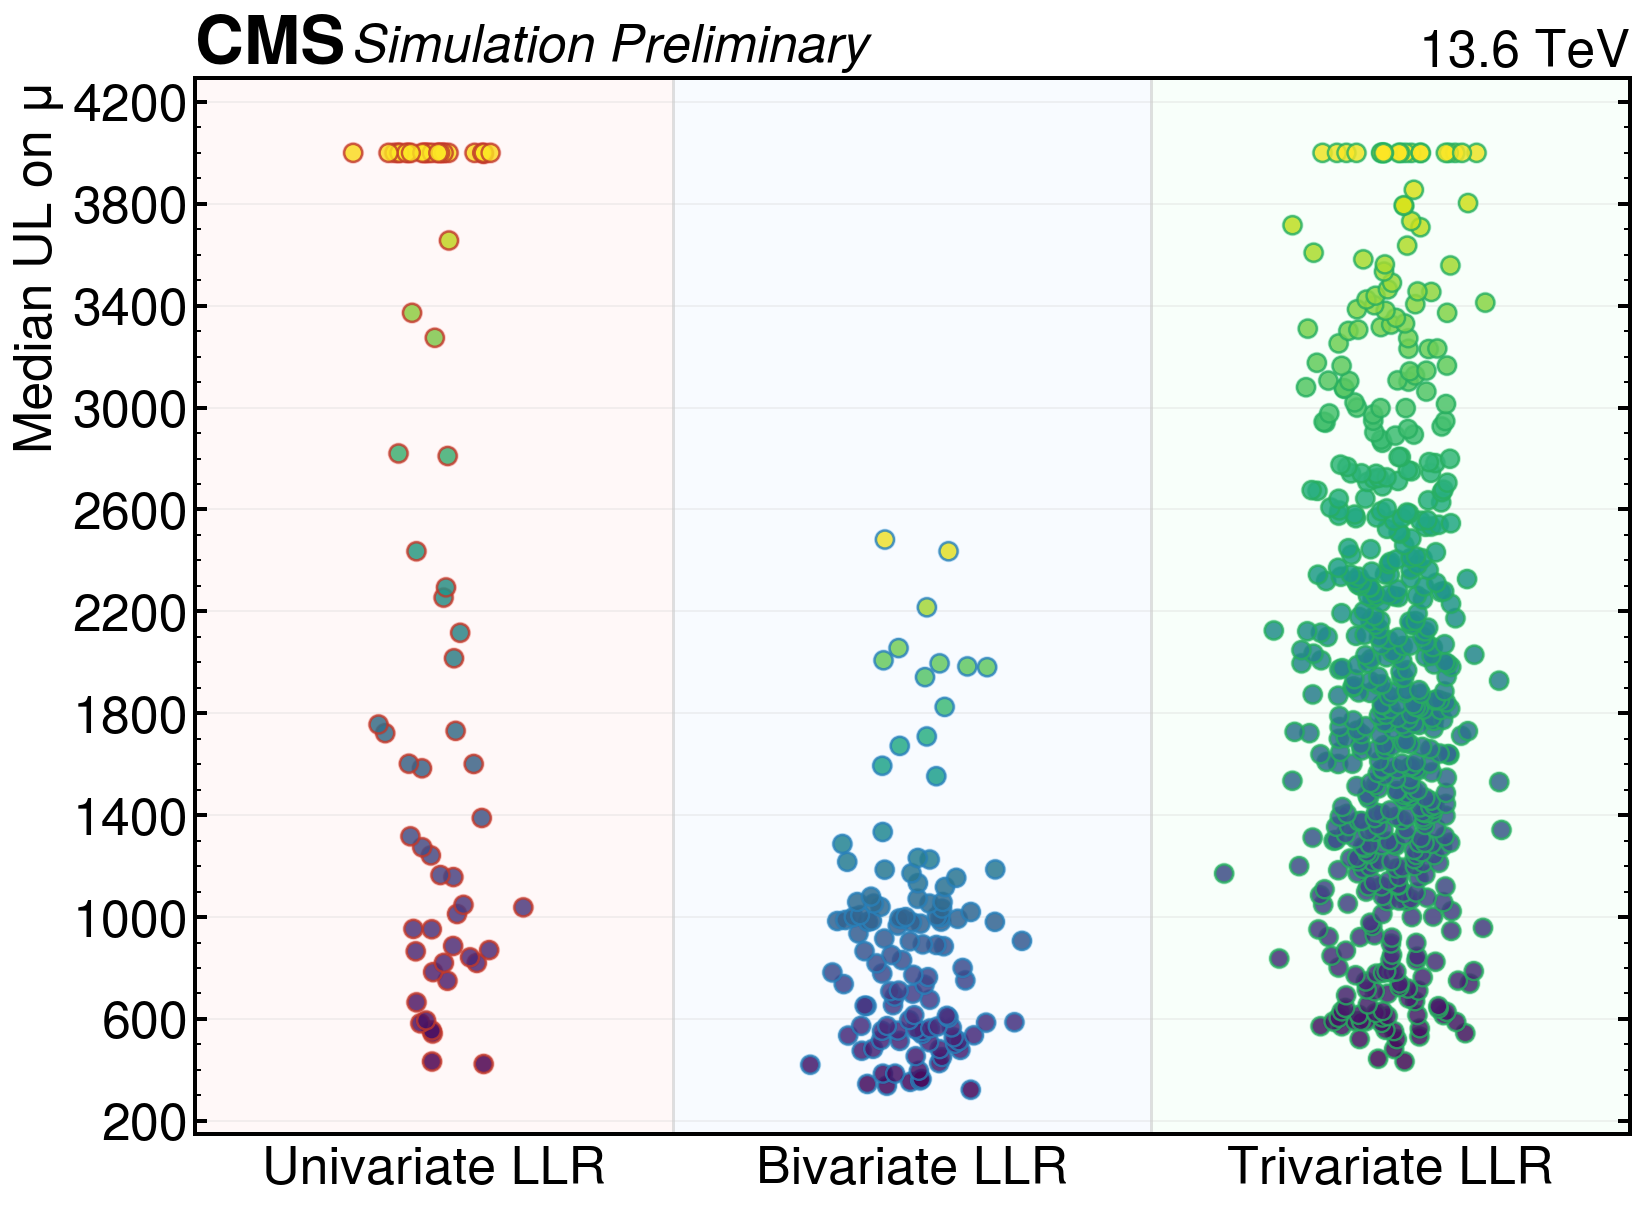

In [ ]:
create_UL_scatter_plot_by_type(df, Path('.') / 'llrs_from_nd_scatterplot_UL.pdf')

In [133]:
def this_create_hierarchical_plot(ranked_df: pd.DataFrame, outfile, ylabel):
    """Create CMS-style hierarchical plot showing individual 1D LLRs with names."""
    
    import mplhep
    import matplotlib.cm as cm
    import numpy as np
    
    mplhep.style.use("CMS")
    
    label_fontsize = 24
    tick_fontsize = 20
    cms_fontsize = 20
    
    # CMS-style figure with proper proportions
    fig, ax = plt.subplots(figsize=(14, max(8, len(ranked_df) * 0.35 + 2)))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Enhanced gradient color scheme - more sophisticated palette
    # Use viridis for better scientific visualization
    norm = plt.Normalize(vmin=ranked_df['mu'].min(), vmax=ranked_df['mu'].max())
    colors = cm.viridis(norm(ranked_df['mu']))
    
    # Add subtle glow effect behind bars
    y_positions = np.arange(len(ranked_df))
    
    # Create glow effect with larger, more transparent bars
    glow_bars = ax.barh(y_positions, ranked_df['mu'], 
                       color=colors, alpha=0.2, edgecolor='none',
                       height=0.9)  # Slightly wider for glow
    
    # Main bars with CMS-style edges
    bars = ax.barh(y_positions, ranked_df['mu'], 
                   color=colors, alpha=0.85, 
                   edgecolor='white', linewidth=1.5,
                   height=0.7)  # Standard height
    
    # CMS-style y-axis labels
    names = [name for name in ranked_df['obs_name']]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(names, fontsize=tick_fontsize)
    
    # CMS-style spines - thick black borders
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color('black')
    
    # CMS-style tick parameters
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=2,
                   labelsize=tick_fontsize, top=True, right=True, 
                   bottom=True, left=True, color='black')
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=1,
                   top=True, right=True, bottom=True, left=True, color='black')
    
    # Remove y-axis tick marks but keep x-axis ticks
    ax.tick_params(axis='y', which='both', length=0)
    
    # Set limits with proper CMS padding
    ax.set_ylim(-0.5, len(ranked_df) - 0.5)
    max_value = max(ranked_df['mu'])
    ax.set_xlim(0, max_value * 1.12)  # Tighter than before for cleaner look
    
    # CMS-style labels
    ax.set_xlabel('Median UL on μ', fontsize=label_fontsize)
    ax.set_ylabel(ylabel, fontsize=label_fontsize)
    
    # CMS-style grid - only vertical lines for horizontal bars
    ax.grid(True, alpha=0.3, axis='x', linestyle='-', linewidth=0.8, color='#cccccc')
    ax.grid(False, axis='y')  # No horizontal grid for cleaner look
    ax.set_axisbelow(True)
    
    # Enhanced value labels with better positioning
    for i, (bar, value) in enumerate(zip(bars, ranked_df['mu'])):
        # Position text more elegantly
        text_x = value + max_value * 0.015
        ax.text(text_x, i, f'{value:.0f}', 
               va='center', ha='left', fontsize=tick_fontsize-2,
               color='#2c3e50', weight='normal',
               bbox=dict(boxstyle='round,pad=0.25', 
                        facecolor='white', 
                        edgecolor='#cccccc',
                        linewidth=0.5,
                        alpha=0.9))
    
    # Add CMS text
    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fontsize, loc=0)
    ax.text(1.0, 1.0, "13.6 TeV", transform=ax.transAxes, fontsize=cms_fontsize,
            horizontalalignment='right', verticalalignment='bottom')
    
    # Add subtle reference line at a meaningful value if appropriate
    # if len(ranked_df) > 5:
    #     median_value = np.median(ranked_df['mu'])
    #     ax.axvline(median_value, color='red', alpha=0.4, linestyle=':', 
    #               linewidth=1.5, zorder=0)
    #     ax.text(median_value + max_value * 0.01, len(ranked_df) - 1, 
    #            f'Median: {median_value:.0f}', 
    #            rotation=90, va='top', ha='left', 
    #            fontsize=tick_fontsize-4, color='red', alpha=0.7)
    
    # Force nice tick spacing on x-axis
    from matplotlib.ticker import MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=False))
    
    plt.tight_layout()
    
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style hierarchical plot saved to {outfile}")
    
    plt.show()

CMS-style hierarchical plot saved to top10_llrs_from_2D.pdf


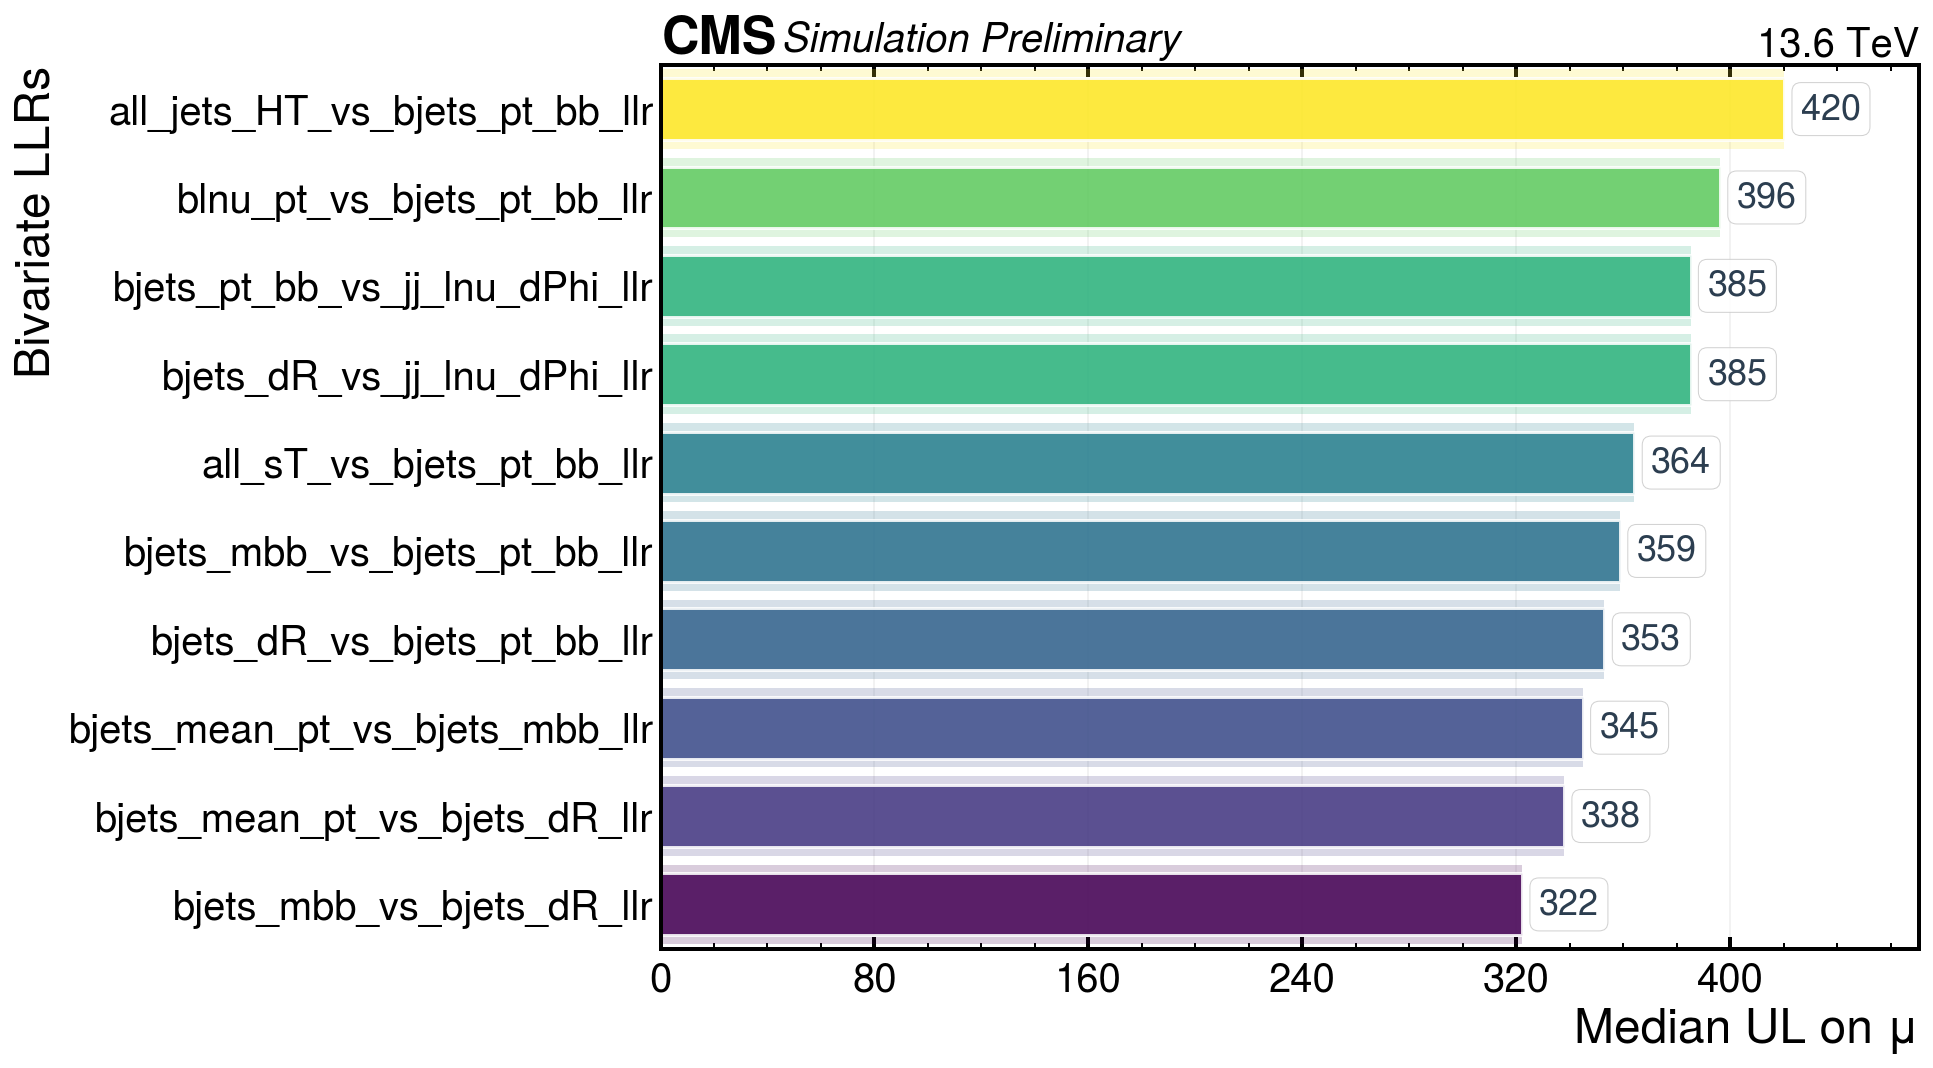

In [134]:
# Filter for rows where obs_type is 'llr_from_2D' or 'llr_from_3D'
filtered_df = df[df['obs_type'].isin(['llr_from_2D'])]
ranked_df = filtered_df.sort_values('mu', ascending=True)
ranked_df = ranked_df.reset_index(drop=True)
top10 = ranked_df.head(10)
this_create_hierarchical_plot(top10, outfile= "top10_llrs_from_2D.pdf", ylabel='Bivariate LLRs')

CMS-style hierarchical plot saved to top10_llrs_from_3D.pdf


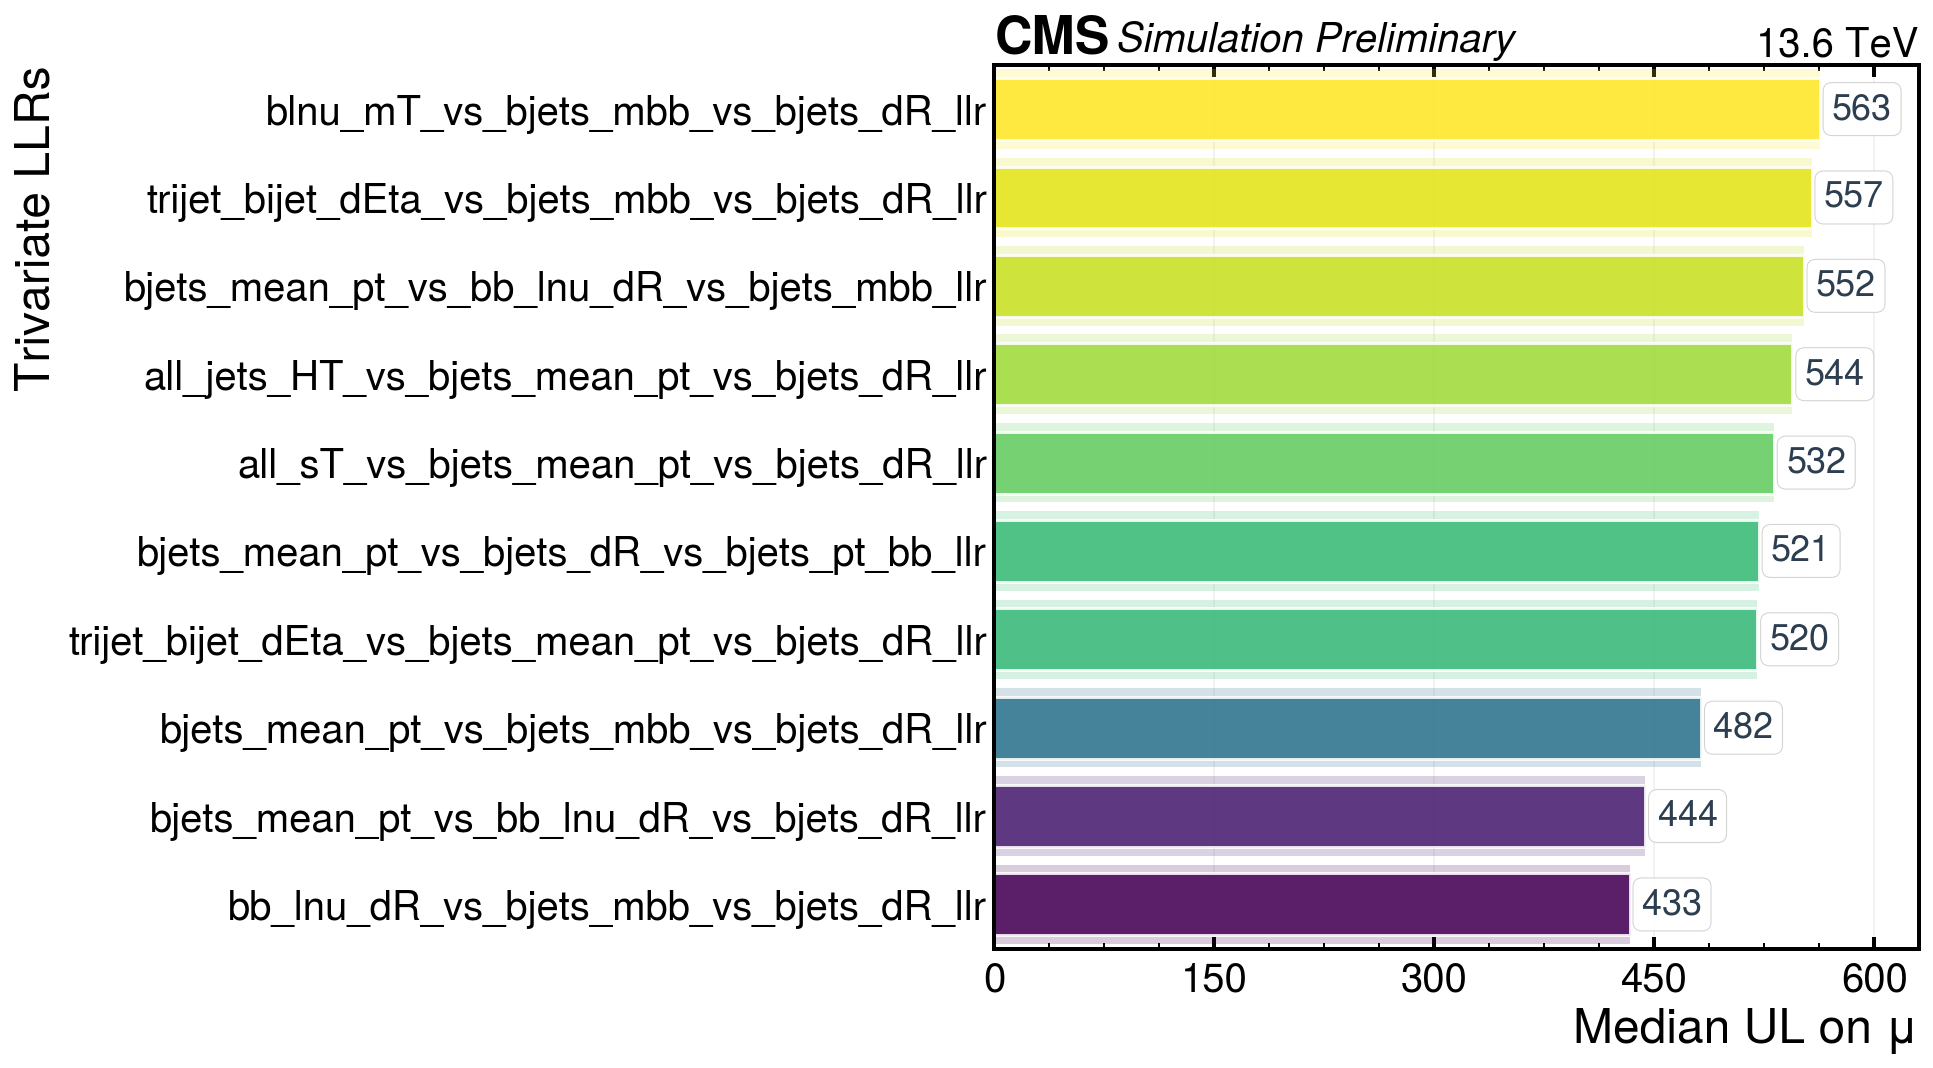

In [135]:
filtered_df = df[df['obs_type'].isin(['llr_from_3D'])]
ranked_df = filtered_df.sort_values('mu', ascending=True)
ranked_df = ranked_df.reset_index(drop=True)
top10 = ranked_df.head(10)
this_create_hierarchical_plot(top10, outfile= "top10_llrs_from_3D.pdf", ylabel='Trivariate LLRs')

Descriptive box plot saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_boxplot_by_type.pdf


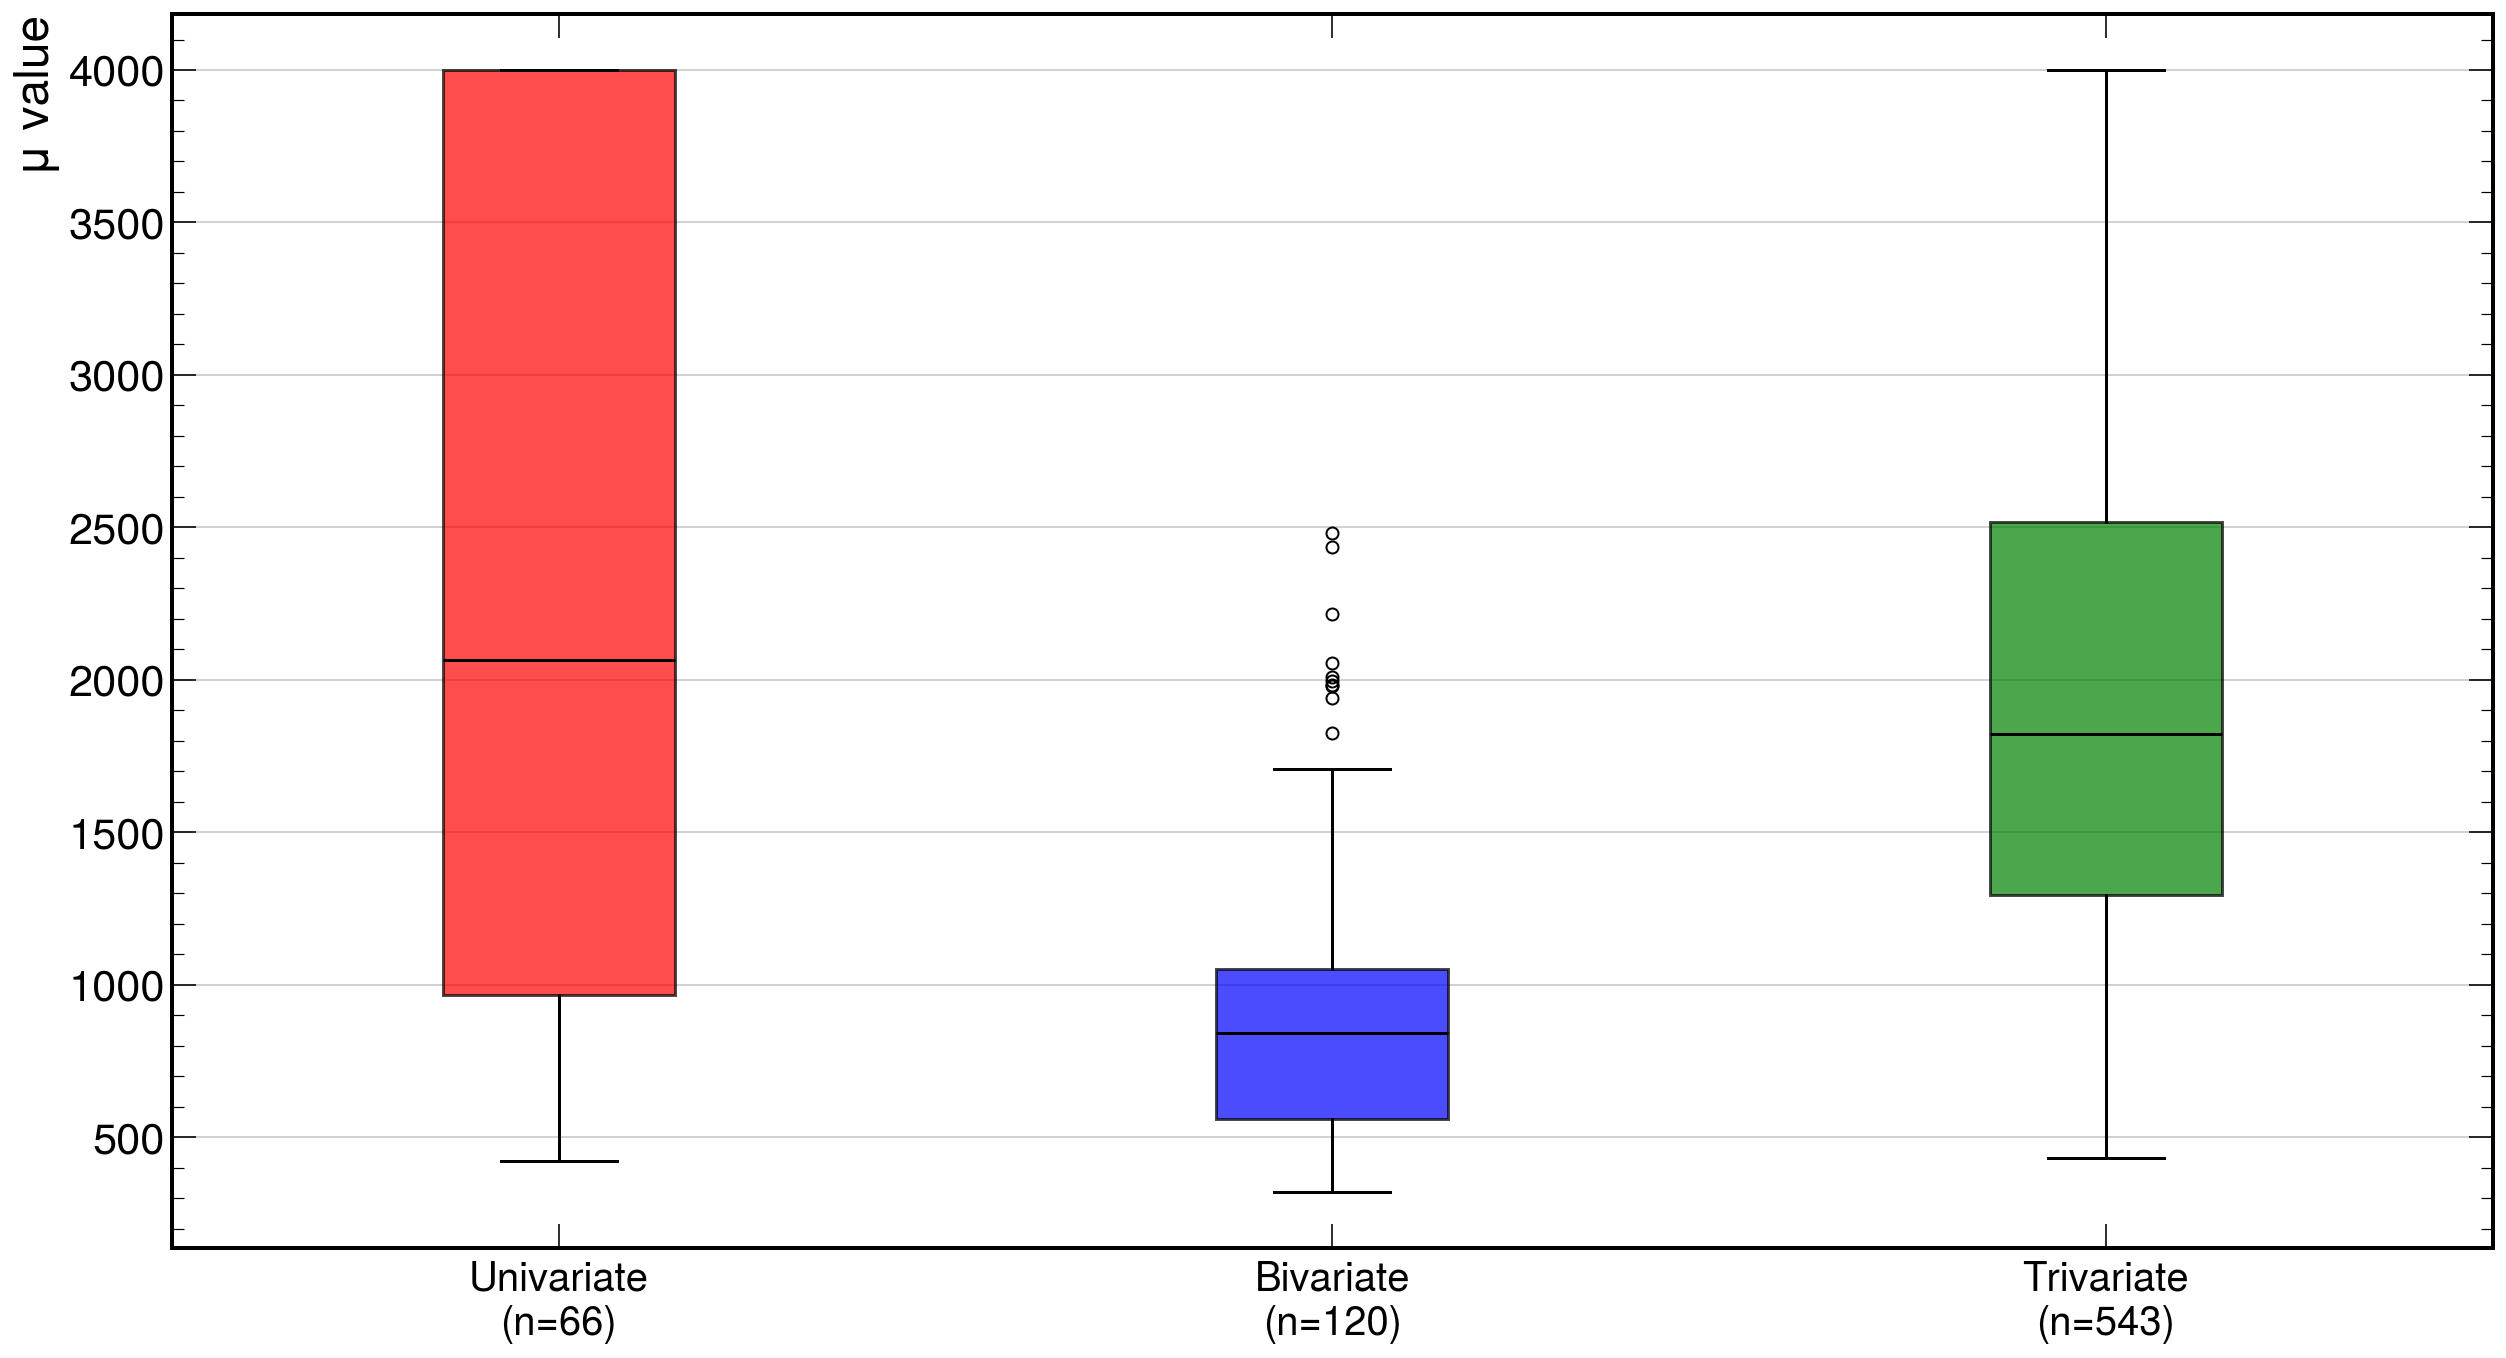

In [8]:
create_UL_box_plot_by_type(df, projectdir)

Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_multivar_trend.pdf


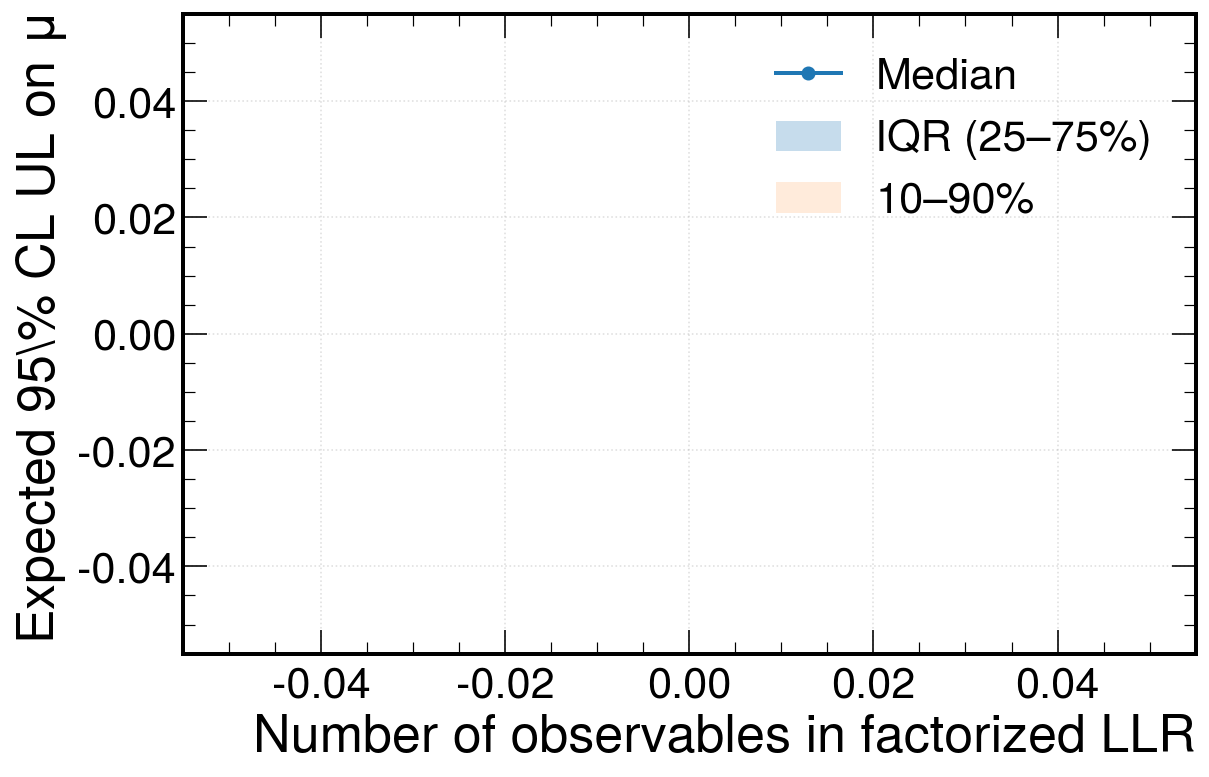

In [9]:
plot_multivar_trend(df, projectdir)

CMS-style hierarchical plot saved to all_llrs_from_1D.pdf


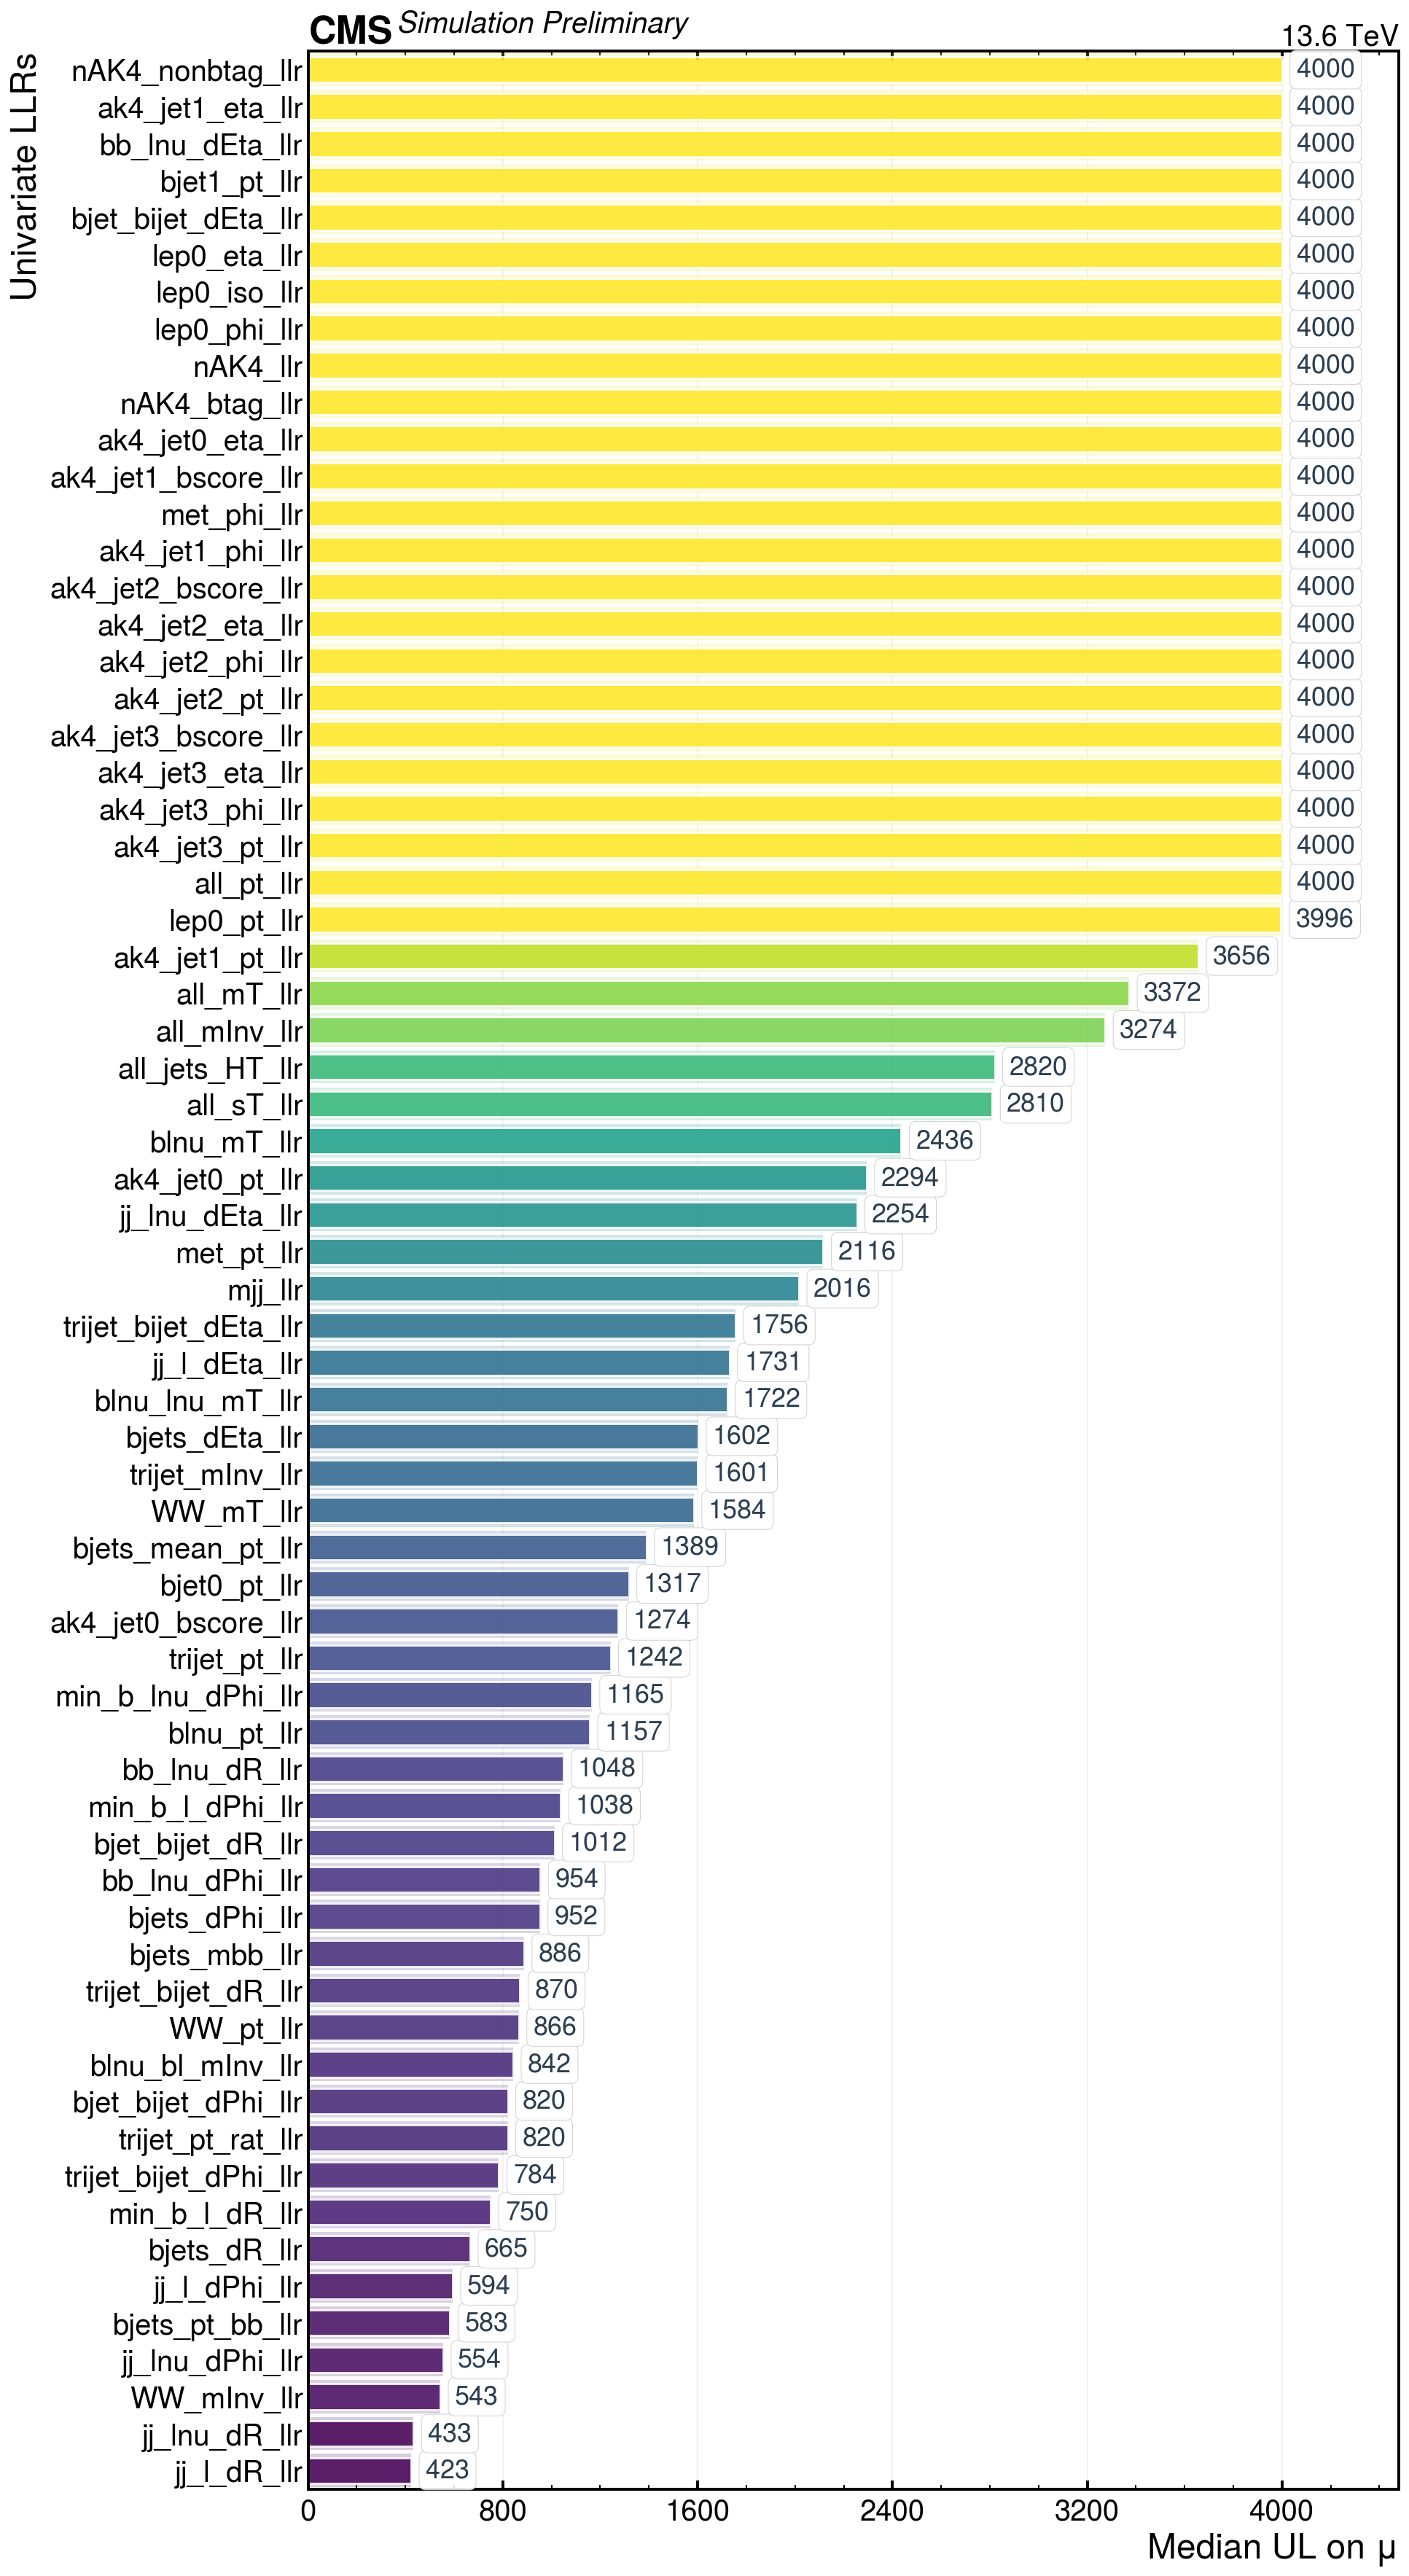

In [137]:
filtered_df = df[df['obs_type'].isin(['llr_from_1D'])]
ranked_df = filtered_df.sort_values('mu', ascending=True)
ranked_df = ranked_df.reset_index(drop=True)
this_create_hierarchical_plot(ranked_df, outfile= "all_llrs_from_1D.pdf", ylabel='Univariate LLRs')

Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_global_scatter.pdf
Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_variable_usage_top10.pdf
Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_greedy_chain.pdf


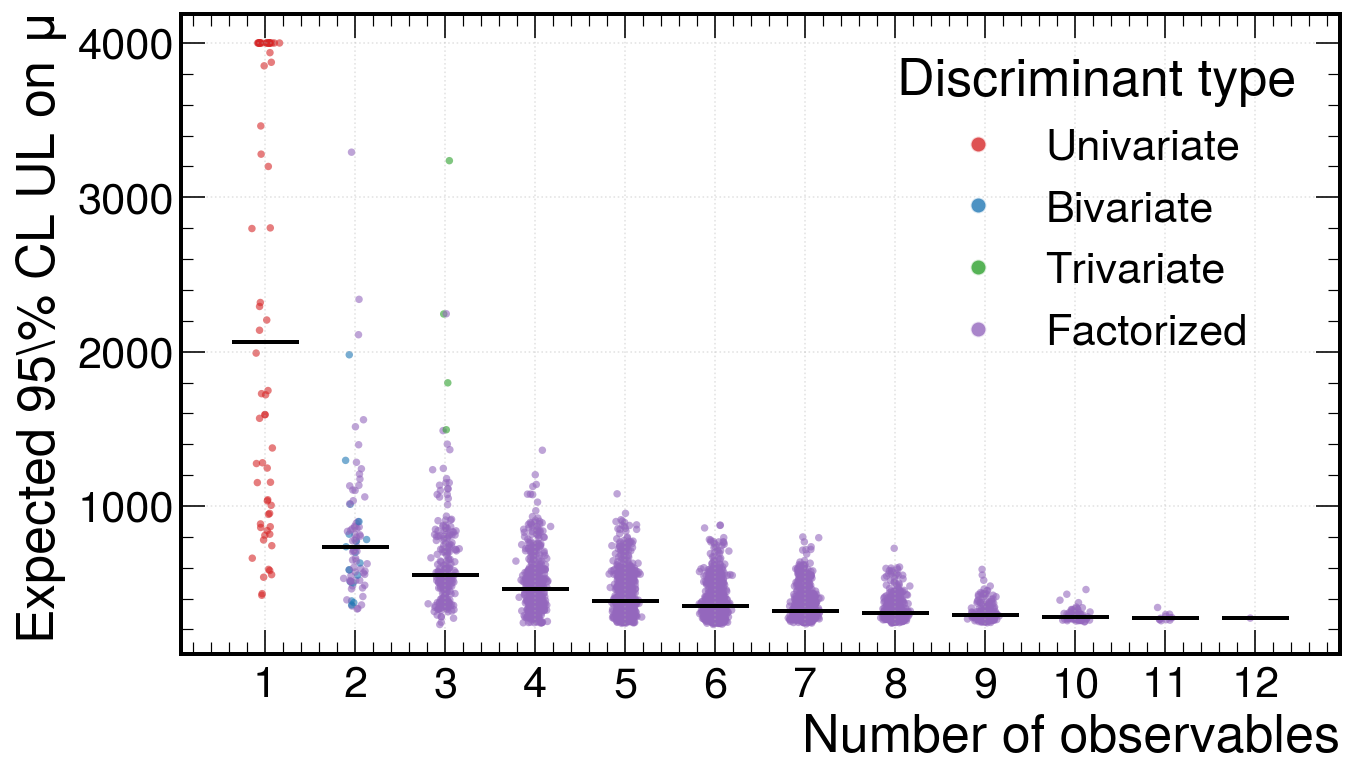

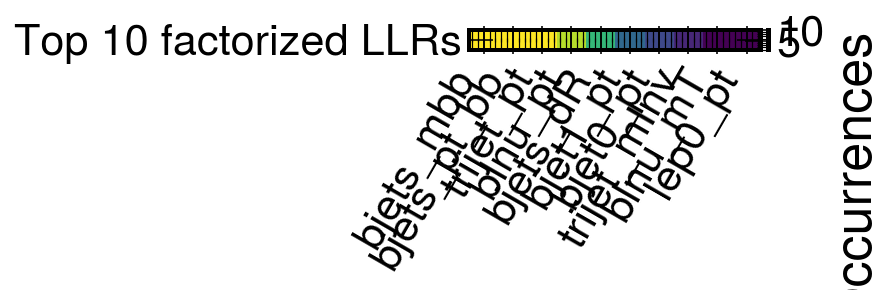

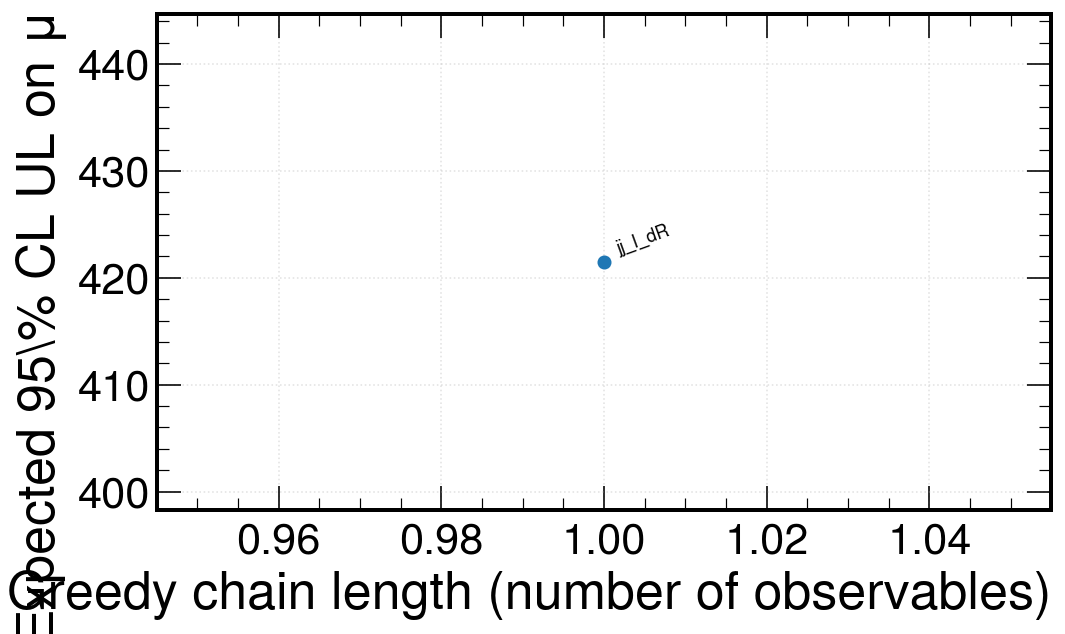

In [11]:
plot_global_scatter(df, projectdir)
plot_variable_usage_heatmap(df, projectdir, 10)
plot_greedy_chain(df, projectdir, max_k=10)

In [19]:
# Create a clean ranking DataFrame
from_1d_ranking = df[df['llr_type'] == 'from_1D'][['llr_name', 'mu_value']].copy()
from_1d_ranking = from_1d_ranking.sort_values('mu_value').reset_index(drop=True)
from_1d_ranking['rank'] = range(1, len(from_1d_ranking) + 1)
from_1d_ranking = from_1d_ranking[['rank', 'llr_name', 'mu_value']]

# Display
print(from_1d_ranking.to_string(index=False))

 rank              llr_name  mu_value
    1           jj_l_dR_llr  421.5000
    2         jj_lnu_dR_llr  432.0000
    3           WW_mInv_llr  538.2500
    4       jj_lnu_dPhi_llr  554.9375
    5       bjets_pt_bb_llr  581.7500
    6         jj_l_dPhi_llr  589.2500
    7          bjets_dR_llr  661.7500
    8        min_b_l_dR_llr  742.7500
    9 trijet_bijet_dPhi_llr  779.7500
   10     trijet_pt_rat_llr  809.7500
   11   bjet_bijet_dPhi_llr  817.2500
   12      blnu_bl_mInv_llr  840.2500
   13             WW_pt_llr  860.7500
   14   trijet_bijet_dR_llr  865.7500
   15         bjets_mbb_llr  883.7500
   16        bjets_dPhi_llr  945.7500
   17       bb_lnu_dPhi_llr  951.8750
   18     bjet_bijet_dR_llr 1004.5000
   19      min_b_l_dPhi_llr 1033.0000
   20         bb_lnu_dR_llr 1040.2500
   21           blnu_pt_llr 1151.5000
   22    min_b_lnu_dPhi_llr 1153.7500
   23         trijet_pt_llr 1245.7500
   24   ak4_jet0_bscore_llr 1275.0000
   25          bjet0_pt_llr 1280.0000
   26     bj

In [26]:
top_10_1d_llrs = from_1d_ranking['llr_name'][:10].to_list()
top_10_1d_llrs


['jj_l_dR_llr',
 'jj_lnu_dR_llr',
 'WW_mInv_llr',
 'jj_lnu_dPhi_llr',
 'bjets_pt_bb_llr',
 'jj_l_dPhi_llr',
 'bjets_dR_llr',
 'min_b_l_dR_llr',
 'trijet_bijet_dPhi_llr',
 'trijet_pt_rat_llr']

In [22]:
reserved = [
    'lep0_pt',                                      
    'bjets_mbb', 'bjets_dR', 'bjets_pt_bb', 'bjet0_pt', 'bjet1_pt',         # bjet-vars
    'blnu_mT', 'blnu_pt',                                                   # leptonic-top 
    'trijet_mInv', 'trijet_pt', 'trijet_pt_rat', 'trijet_bijet_dR'          # hadronic-top 
]
# Create the full LLR names by adding '_llr' suffix
reserved_llr_names = [var + '_llr' for var in reserved]

# Filter the ranking for only the reserved LLRs
reserved_ranking = from_1d_ranking[from_1d_ranking['llr_name'].isin(reserved_llr_names)].copy()

# Display the results
print(f"Ranking of Reserved LLRs ({len(reserved_ranking)} out of {len(reserved)} found):")
print("-" * 60)
for _, row in reserved_ranking.iterrows():
    print(f"{row['rank']:2d}. {row['llr_name']:<25} μ = {row['mu_value']:8.3f}")

# Check if any reserved LLRs are missing
missing_llrs = set(reserved_llr_names) - set(reserved_ranking['llr_name'])
if missing_llrs:
    print(f"\nMissing from 1D rankings: {missing_llrs}")

Ranking of Reserved LLRs (12 out of 12 found):
------------------------------------------------------------
 5. bjets_pt_bb_llr           μ =  581.750
 7. bjets_dR_llr              μ =  661.750
10. trijet_pt_rat_llr         μ =  809.750
14. trijet_bijet_dR_llr       μ =  865.750
15. bjets_mbb_llr             μ =  883.750
21. blnu_pt_llr               μ = 1151.500
23. trijet_pt_llr             μ = 1245.750
25. bjet0_pt_llr              μ = 1280.000
28. trijet_mInv_llr           μ = 1591.500
37. blnu_mT_llr               μ = 2318.500
44. lep0_pt_llr               μ = 3875.000
52. bjet1_pt_llr              μ = 4000.000
